# Born effective charge diagonal - predicted vs DFT (revPBE)

Scatter of every diagonal element `Z*_iaa` (a = x, y, z), model on the y-axis, VASP on the x-axis.

- arms: `sea-lr-eq_sA` (water interface, `w = 0.02`), `deepmd-cace-eq_sA` (its FastLearn replicate through `deepmd_cace`, `w = 1.0`), and the two native-cace arms `cace-lr` / `cace-sea-lr` (`w = 1.0`); the first figure shows the first arm
- model: `sea-lr-eq_sA/best_model.pth` (n_out=1, `remove_self_interaction=true`, `ChargeEqLatent` w=10)
- dataset: `BEC/` - 100 revPBE snapshots of bulk liquid water (64 H2O, 192 atoms, cubic 12.429 A)
- convention: **PBC dephased** (the periodic Z*), scaled to physical units by `sqrt(w * eps_inf)`
  with `w = 0.02` (long-range weight) and `eps_inf = 1.78`
- sign: fixed to the physical convention (Z*_O < 0); the learned-charge overall sign is a gauge

In [1]:
import os, sys
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "")
os.environ.setdefault("DEEPMD_CACE_DEVICE", "cpu")

WS = "/root/app/deepmd-les/deepmd-les/desc_bridging"
sys.path.insert(0, WS)

import numpy as np
import torch
import check_bec as CB
import check_bec_arm as CBA
from eval_vasp_bec import (ATOMIC_NUMBER, EPS_INF, PHYS_SCALE, lr_weight_of,
                           read_poscar, read_outcar_bec)

VASP_DIR = "/root/app/deepmd-les/BEC"
NFRAMES = 100
RUNS_WI = os.path.join(WS, "..", "DeePMD-kit-FastLearn", "campaign_water_interface",
                       "deepmd", "runs")
RUNS_FL = os.path.join(WS, "..", "DeePMD-kit-FastLearn", "campaign_fastlearn",
                       "deepmd", "runs")


def vasp_frames(nframes=NFRAMES):
    """The VASP reference, read once and shared by every arm below."""
    indices = sorted(int(f.split(".")[1])
                     for f in os.listdir(os.path.join(VASP_DIR, "poscars")))[:nframes]
    frames = []
    for idx in indices:
        coord, cell, elem = read_poscar(os.path.join(VASP_DIR, "poscars", f"POSCAR.{idx}"))
        ref = read_outcar_bec(os.path.join(VASP_DIR, "outcars", f"OUTCAR.{idx}"))
        frames.append(dict(coord=coord, cell=cell, elem=elem, ref=ref))
    return frames


def score_deepmd_arm(ckpt, frames):
    """Raw, sign-fixed `Z*_aa` for a `deepmd_cace` checkpoint, plus its own scale.

    Positions take the *charge head's* dtype, not the descriptor's: a checkpoint
    may mix precisions, and `DeepmdSeAInput` casts its output back to whatever
    dtype it was handed, so the head is what has to match (see
    `check_bec.model_dtype`). The scale is read off the checkpoint's own config
    rather than assumed, because the deepmd arms here weight the long-range term
    differently (`0.02` against `1.0`).
    """
    model = CB.load_model(ckpt)
    head = CB.charge_head_of(model)
    dtype = CB.model_dtype(model)
    w, source = lr_weight_of(ckpt)
    pred_f, dft_f, elem_f = [], [], []
    for fr in frames:
        elem, ref = fr["elem"], fr["ref"]
        numbers = torch.tensor([ATOMIC_NUMBER[e] for e in elem])
        pos = torch.tensor(fr["coord"], dtype=dtype, requires_grad=True)
        cellt = torch.tensor(fr["cell"], dtype=dtype).reshape(1, 3, 3)
        batch = torch.zeros(len(elem), dtype=torch.int64)
        _, q_ker = CBA.kernel_charges(model, head, pos, cellt, batch, numbers)
        bec = CB.born_charges(pos, cellt, batch, q_ker, True)      # dephased, [n,3,3]
        pred_f.append(np.diagonal(bec, axis1=1, axis2=2))          # Z*_aa, [n,3]
        dft_f.append(np.diagonal(ref, axis1=1, axis2=2))           # DFT Z*_aa, [n,3]
        elem_f.append(elem)
    signed = np.concatenate([d.ravel() for d in pred_f])
    dft = np.concatenate([d.ravel() for d in dft_f])
    ef = np.concatenate([np.repeat(e, 3) for e in elem_f])
    # to physical units, sign fixed to the physical convention (Z*_O < 0); the
    # learned-charge overall sign is a gauge.
    sign = -1.0 if signed[ef == "O"].mean() > 0 else 1.0
    return dict(signed=signed * sign, dft=dft, ef=ef, sign=sign, w=w,
                scale=np.sqrt(w * EPS_INF), source=source, dtype=str(dtype),
                model=model)


frames = vasp_frames()
ARM_A = "sea-lr-eq_sA"
arm_a = score_deepmd_arm(os.path.join(RUNS_WI, ARM_A, "best_model.pth"), frames)

pred, dft, elem_flat = arm_a["signed"] * arm_a["scale"], arm_a["dft"], arm_a["ef"]

print(f"frames = {len(frames)}   dots = {pred.size:,}  "
      f"(O {int((elem_flat == 'O').sum()):,}, H {int((elem_flat == 'H').sum()):,})")
print(f"{ARM_A}: dtype {arm_a['dtype']}   "
      f"SCALE = sqrt(w * eps_inf) = sqrt({arm_a['w']:g} * {EPS_INF}) = {arm_a['scale']:.4f}"
      f"   (w from {arm_a['source']})   sign gauge x{arm_a['sign']:+.0f}")

To get the best performance, it is recommended to adjust the number of threads by setting the environment variables OMP_NUM_THREADS, DP_INTRA_OP_PARALLELISM_THREADS, and DP_INTER_OP_PARALLELISM_THREADS. See https://deepmd.rtfd.io/parallelism/ for more information.


frames = 100   dots = 57,600  (O 19,200, H 38,400)
sea-lr-eq_sA: dtype torch.float32   SCALE = sqrt(w * eps_inf) = sqrt(0.02 * 1.78) = 0.1887   (w from long_range.weight)   sign gauge x-1


In [2]:
def rmse_r2(p, d):
    rmse = float(np.sqrt(np.mean((p - d) ** 2)))
    r2 = float(1.0 - np.sum((p - d) ** 2) / np.sum((d - d.mean()) ** 2))
    return rmse, r2

rmse_all, r2_all = rmse_r2(pred, dft)
print(f"{'':6s}{'n':>8s}{'RMSE':>9s}{'R^2':>9s}{'MAE':>9s}{'bias':>9s}")
for name in ("all", "O", "H"):
    m = np.ones_like(dft, dtype=bool) if name == "all" else (elem_flat == name)
    rmse, r2 = rmse_r2(pred[m], dft[m])
    mae = float(np.mean(np.abs(pred[m] - dft[m])))
    bias = float(np.mean(pred[m] - dft[m]))
    print(f"{name:6s}{m.sum():8,d}{rmse:9.4f}{r2:9.4f}{mae:9.4f}{bias:+9.4f}")

             n     RMSE      R^2      MAE     bias
all     57,600   0.0898   0.9816   0.0659  +0.0072
O       19,200   0.1119   0.4247   0.0901  +0.0338
H       38,400   0.0765   0.8293   0.0538  -0.0061


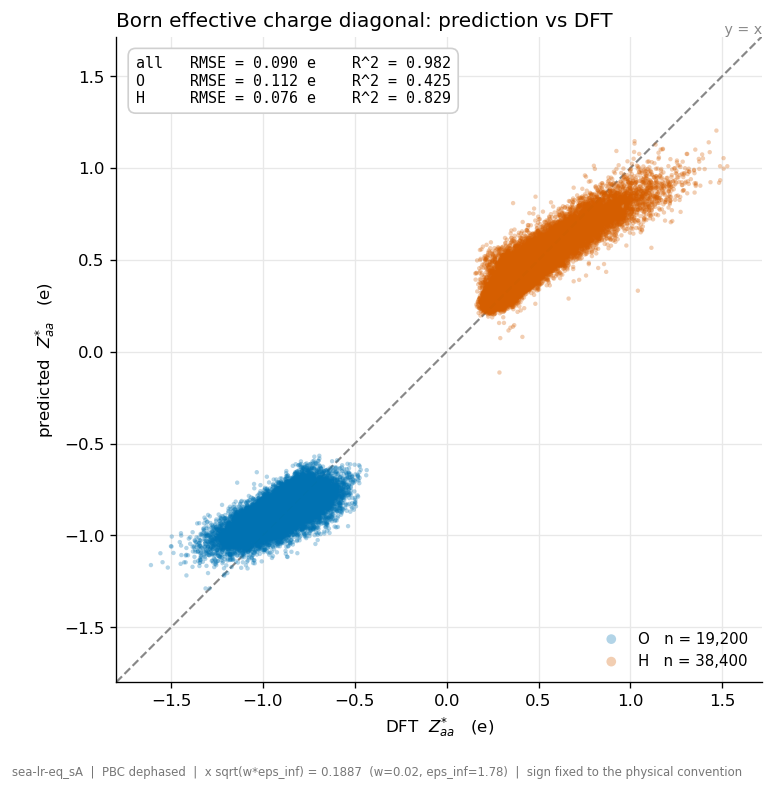

In [3]:
import matplotlib.pyplot as plt

COLORS = {"O": "#0072B2", "H": "#D55E00"}   # Okabe-Ito blue / vermillion
lo = min(pred.min(), dft.min())
hi = max(pred.max(), dft.max())
pad = 0.06 * (hi - lo)
lo, hi = lo - pad, hi + pad

fig, ax = plt.subplots(figsize=(6.6, 6.6), dpi=120)
ax.plot([lo, hi], [lo, hi], color="#888888", lw=1.3, ls="--", zorder=1)
ax.text(hi, hi, " y = x", color="#888888", fontsize=8.5, ha="right", va="bottom")

for e in ("O", "H"):
    m = elem_flat == e
    ax.scatter(dft[m], pred[m], s=7, alpha=0.30, color=COLORS[e],
               edgecolors="none", label=f"{e}   n = {int(m.sum()):,}", zorder=3)

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal")
ax.set_xlabel(r"DFT  $Z^{*}_{aa}$   (e)")
ax.set_ylabel(r"predicted  $Z^{*}_{aa}$   (e)")
ax.set_title("Born effective charge diagonal: prediction vs DFT", fontsize=12, loc="left")
ax.grid(color="#e8e8e8", lw=0.8, zorder=0)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)

rmse_o, r2_o = rmse_r2(pred[elem_flat == "O"], dft[elem_flat == "O"])
rmse_h, r2_h = rmse_r2(pred[elem_flat == "H"], dft[elem_flat == "H"])
stats = (f"all   RMSE = {rmse_all:.3f} e    R^2 = {r2_all:.3f}\n"
         f"O     RMSE = {rmse_o:.3f} e    R^2 = {r2_o:.3f}\n"
         f"H     RMSE = {rmse_h:.3f} e    R^2 = {r2_h:.3f}")
ax.text(0.03, 0.97, stats, transform=ax.transAxes, va="top", ha="left",
        fontsize=9, family="monospace",
        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#d0d0d0"))
ax.legend(loc="lower right", frameon=False, fontsize=9, markerscale=2.2)

note = (f"{ARM_A}  |  PBC dephased  |  x sqrt(w*eps_inf) = {arm_a['scale']:.4f}  "
        f"(w={arm_a['w']:g}, eps_inf={EPS_INF})  |  sign fixed to the physical convention")
fig.text(0.012, 0.012, note, fontsize=7, color="#777777")
plt.tight_layout(rect=(0, 0.035, 1, 1))
plt.show()

---
# The `cace-sea-lr` replicate through `deepmd_cace`, with charge equalization

`campaign_fastlearn/deepmd/runs/deepmd-cace-eq_sA` is `cace-sea-lr`'s graph rebuilt inside DeepMD: a DeepMD `se_a` descriptor feeding CACE's `Atomwise` heads, trained by `python -m deepmd_cace input.json` with cace's own recipe transcribed from `cace/fit_cace.py` - four phases run as eight fits, 500 epochs x 160 steps = 80,000 steps, Adam 1e-2 with `StepLR(20, 0.5)`, force weight 1000, batch 2, seed 10.
The graph is `DeepmdSeAInput -> Atomwise(SR_energy) -> Atomwise(q) -> ChargeEqLatent -> FeatureAdd -> Forces`, and the built model has 119,478 trainable parameters - exactly the `n_trainable_params` recorded for `cace-sea-lr`, since the equalizer is parameter-free.

Two things differ from `cace-sea-lr`, and both are pinned by the checkpoint's own config rather than assumed.

**1. The equalizer is on.** `long_range.charge_eq_latent` at `w = 10` replaces the head's proposal `q` with the KKT solution of `min_q 1/2 q^T A q + w ||q - q_r||^2` subject to `1^T q = 0`, so the Ewald term sees an exactly neutral charge set that is held within `w` of the learned one.
The water-interface arm above runs the same equalizer at the same `w = 10`; what differs there is the long-range weight, `0.02` against `1.0` here.

**2. `ewald.remove_self_interaction: false`, written out explicitly**, matching `cace-sea-lr`. The two cace checkouts disagree on that default (`cace-ts` false, `/root/app/cace` true), so leaving it implicit would make the comparison depend on which one is imported.

The long-range weight is read off the checkpoint rather than passed in: `combine_potentials: false` is the `FeatureAdd` path, which carries no weight, matching the `lr_mix_weight: 1.0` recorded for `cace-sea-lr`, so this arm's scale is `sqrt(1.0 * 1.78) = 1.3342`.
Scoring it needs no subprocess. It runs on the same `cace` checkout this notebook already holds, and the pod's copy of that checkout is the same commit with an identical hash over every `.py` file, so the arm is scored by the same code it trained under.

In [4]:
ARM_B = "deepmd-cace-eq_sA"
arm_b = score_deepmd_arm(os.path.join(RUNS_FL, ARM_B, "best_model.pth"), frames)

pred_b = arm_b["signed"] * arm_b["scale"]
dft_b, elem_b = arm_b["dft"], arm_b["ef"]

print(f"{ARM_B}: dtype {arm_b['dtype']}   "
      f"SCALE = sqrt(w * eps_inf) = sqrt({arm_b['w']:g} * {EPS_INF}) = {arm_b['scale']:.4f}"
      f"   (w from {arm_b['source']})   sign gauge x{arm_b['sign']:+.0f}")
print(f"{'':6s}{'n':>8s}{'RMSE':>9s}{'R^2':>9s}{'MAE':>9s}{'bias':>9s}")
for name in ("all", "O", "H"):
    m = np.ones_like(dft_b, dtype=bool) if name == "all" else (elem_b == name)
    rmse, r2 = rmse_r2(pred_b[m], dft_b[m])
    mae = float(np.mean(np.abs(pred_b[m] - dft_b[m])))
    bias = float(np.mean(pred_b[m] - dft_b[m]))
    print(f"{name:6s}{m.sum():8,d}{rmse:9.4f}{r2:9.4f}{mae:9.4f}{bias:+9.4f}")

deepmd-cace-eq_sA: dtype torch.float32   SCALE = sqrt(w * eps_inf) = sqrt(1 * 1.78) = 1.3342   (w from FeatureAdd (unit weight))   sign gauge x-1
             n     RMSE      R^2      MAE     bias
all     57,600   0.1151   0.9697   0.0951  +0.0089
O       19,200   0.1467   0.0109   0.1228  -0.1104
H       38,400   0.0955   0.7336   0.0812  +0.0685


---
# Cross-code: the two native-cace arms

`campaign_fastlearn/cace/runs/cace-lr` and `cace-sea-lr`, evaluated on the same
100 VASP snapshots with the same dephased convention.

Three things differ from the arm above, and all are recorded rather than assumed:

**1. These are plain cace models, not `deepmd_cace`.**
Their neighbour list comes from `cace.data.AtomicData` (the transform their training used), and the checkpoint is either cace's own whole-module pickle (`cace-lr`) or the seam state dict (`cace-sea-lr`, via `sea_seam.load_sea_checkpoint`) - a bare `torch.load` would silently load nothing into the latter.
`check_bec_cace.py` holds both paths.

**2. The long-range weight is 1.0, not 0.02.**
These arms add the Ewald term with `FeatureAdd` (unweighted), which `deepmd/gen_inputs.py` reads as the faithful copy of cace adding `E_LR` to `E_SR` at weight 1.
So `sqrt(w * eps_inf)` here is `sqrt(1.0 * 1.78) = 1.3342`, not `0.1887`.

**3. They need the other cace checkout, so they run in a subprocess.**
`check_bec` above imports whatever `cace` the editable install points at (`/root/app/cace`), while these checkpoints were written under `/root/app/cace-ts`, whose `AngularComponent` stores `lxlylz_dict` with string keys (`'1_0_0'`).
Unpickling `cace-lr` against `/root/app/cace` gives a module whose keys are strings but whose forward does `l - 1` on them, i.e. `TypeError: unsupported operand type(s) for -: 'str' and 'int'`.
Python module identity is global, so the two arms cannot share a process; the next cell shells out to `check_bec_cace.py --dump` and reads the arrays back.

The charge unit does *not* differ: cace's kernel is `norm_factor = 1.0`, whose charge is `sqrt(4 pi eps_0) e` times the physical one, and `Polarization`'s default `normalization_factor = 1/9.48933` undoes exactly that.
The plain conversion (`x1`) is reported alongside the `sqrt(w*eps_inf)` one, since whether the `eps_inf` factor belongs here is what the DFT comparison tests.

In [5]:
import subprocess
import check_bec_cace as CBC

CACE_ARMS = ("cace-lr", "cace-sea-lr")
CACE_NPZ = os.path.join(WS, "cace_bec.npz")

# The cace checkpoints need /root/app/cace-ts, but this process already holds
# cace from /root/app/cace (cell 1) and module identity is global - see the
# markdown above. So the scoring runs in a subprocess that has only cace-ts.
inputs = [os.path.join(WS, "check_bec_cace.py"),
          os.path.join(CBC.RUNS, "cace-lr", "best_model.pth"),
          os.path.join(CBC.RUNS, "cace-sea-lr", "best_model.pth")]
fresh = os.path.exists(CACE_NPZ) and all(
    os.path.getmtime(CACE_NPZ) > os.path.getmtime(p) for p in inputs)
if fresh:
    print(f"reusing {os.path.basename(CACE_NPZ)} (newer than the script and both checkpoints)")
else:
    res = subprocess.run(
        [sys.executable, "check_bec_cace.py", "--dump", CACE_NPZ,
         "--frames", str(NFRAMES)], cwd=WS, capture_output=True, text=True)
    if res.returncode:
        raise RuntimeError(res.stderr[-2000:])
    print(res.stdout.strip())

z = np.load(CACE_NPZ, allow_pickle=False)
CACE_SCALE = float(np.sqrt(z["lr_weight"] * z["eps_inf"]))   # FeatureAdd: w = 1.0
dft_cace, elem_cace = z["cace-lr_dft"], z["cace-lr_elem"]

cace = {}
for arm in CACE_ARMS:
    signed = z[f"{arm}_signed"]                 # raw, sign fixed to Z*_O < 0
    q0, e0 = z[f"{arm}_q0"], z[f"{arm}_q0_elem"]
    cace[arm] = dict(signed=signed, pred=signed * CACE_SCALE, ef=z[f"{arm}_elem"],
                     dft=z[f"{arm}_dft"], sign=float(z[f"{arm}_sign"]),
                     dtype=str(z[f"{arm}_dtype"]), q0=q0, q0_elem=e0)
    print(f"{arm:12s} dtype {str(z[f'{arm}_dtype']):15s} "
          f"sign gauge x{float(z[f'{arm}_sign']):+.0f}   "
          f"q (cace units, frame 0)  O {q0[e0 == 'O'].mean():+.3f}  "
          f"H {q0[e0 == 'H'].mean():+.3f}")

print(f"\nthe deepmd arm above used its own scale {PHYS_SCALE:.4f} "
      f"= sqrt(0.02 * 1.78); these use {CACE_SCALE:.4f} = sqrt(1.0 * 1.78)")

reusing cace_bec.npz (newer than the script and both checkpoints)
cace-lr      dtype torch.float32   sign gauge x+1   q (cace units, frame 0)  O -3.523  H +1.815
cace-sea-lr  dtype torch.float64   sign gauge x-1   q (cace units, frame 0)  O +7.229  H -3.788

the deepmd arm above used its own scale 0.1887 = sqrt(0.02 * 1.78); these use 1.3342 = sqrt(1.0 * 1.78)


In [6]:
vasp_o = dft_cace[elem_cace == "O"].mean()
vasp_h = dft_cace[elem_cace == "H"].mean()

# the two scoring paths parse the same 100 VASP files, so their reference has to
# agree element for element; if it does not, the rows below are not comparable
assert np.array_equal(elem_b, elem_cace), "element order differs between scorers"
assert np.allclose(dft_b, dft_cace, atol=1e-10), "DFT reference differs between scorers"
assert np.array_equal(elem_flat, elem_cace), "element order differs between scorers"

arms = {
    "deepmd sea-lr-eq_sA": dict(pred=pred, dft=dft, ef=elem_flat),
    "deepmd-cace-eq_sA": dict(pred=pred_b, dft=dft_b, ef=elem_b),
    "cace-lr": cace["cace-lr"],
    "cace-sea-lr": cace["cace-sea-lr"],
}

print(f"{'arm':22s}{'Z*_O':>8s}{'Z*_H':>8s}{'RMSE':>8s}{'R^2':>8s}"
      f"{'O RMSE':>8s}{'O R^2':>8s}{'H RMSE':>8s}{'H R^2':>8s}{'O std':>8s}")
print(f"{'VASP (revPBE)':22s}{vasp_o:+8.3f}{vasp_h:+8.3f}{'':>32s}"
      f"{dft_cace[elem_cace == 'O'].std():8.3f}")
for name, a in arms.items():
    p, d, ef = a["pred"], a["dft"], a["ef"]
    o, h = ef == "O", ef == "H"
    rm, r2 = rmse_r2(p, d)
    rmo, r2o = rmse_r2(p[o], d[o])
    rmh, r2h = rmse_r2(p[h], d[h])
    print(f"{name:22s}{p[o].mean():+8.3f}{p[h].mean():+8.3f}{rm:8.4f}{r2:8.4f}"
          f"{rmo:8.3f}{r2o:8.3f}{rmh:8.3f}{r2h:8.3f}{p[o].std():8.3f}")

print("\nsame, but with the plain conversion x1 (no sqrt(w*eps_inf)) for the cace arms")
for arm in CACE_ARMS:
    a = cace[arm]
    p, d, ef = a["signed"], dft_cace, a["ef"]
    o, h = ef == "O", ef == "H"
    rm, r2 = rmse_r2(p, d)
    rmo, r2o = rmse_r2(p[o], d[o])
    rmh, r2h = rmse_r2(p[h], d[h])
    print(f"{arm:22s}{p[o].mean():+8.3f}{p[h].mean():+8.3f}{rm:8.4f}{r2:8.4f}"
          f"{rmo:8.3f}{r2o:8.3f}{rmh:8.3f}{r2h:8.3f}{p[o].std():8.3f}")

arm                       Z*_O    Z*_H    RMSE     R^2  O RMSE   O R^2  H RMSE   H R^2   O std
VASP (revPBE)           -0.903  +0.451                                   0.147
deepmd sea-lr-eq_sA     -0.869  +0.445  0.0898  0.9816   0.112   0.425   0.076   0.829   0.091
deepmd-cace-eq_sA       -1.013  +0.520  0.1151  0.9697   0.147   0.011   0.096   0.734   0.097
cace-lr                 -0.837  +0.446  0.0637  0.9907   0.091   0.617   0.044   0.944   0.123
cace-sea-lr             -0.979  +0.508  0.1002  0.9771   0.124   0.289   0.086   0.786   0.103

same, but with the plain conversion x1 (no sqrt(w*eps_inf)) for the cace arms
cace-lr                 -0.627  +0.334  0.1975  0.9109   0.286  -2.748   0.133   0.482   0.092
cace-sea-lr             -0.733  +0.381  0.1455  0.9516   0.199  -0.813   0.110   0.648   0.077


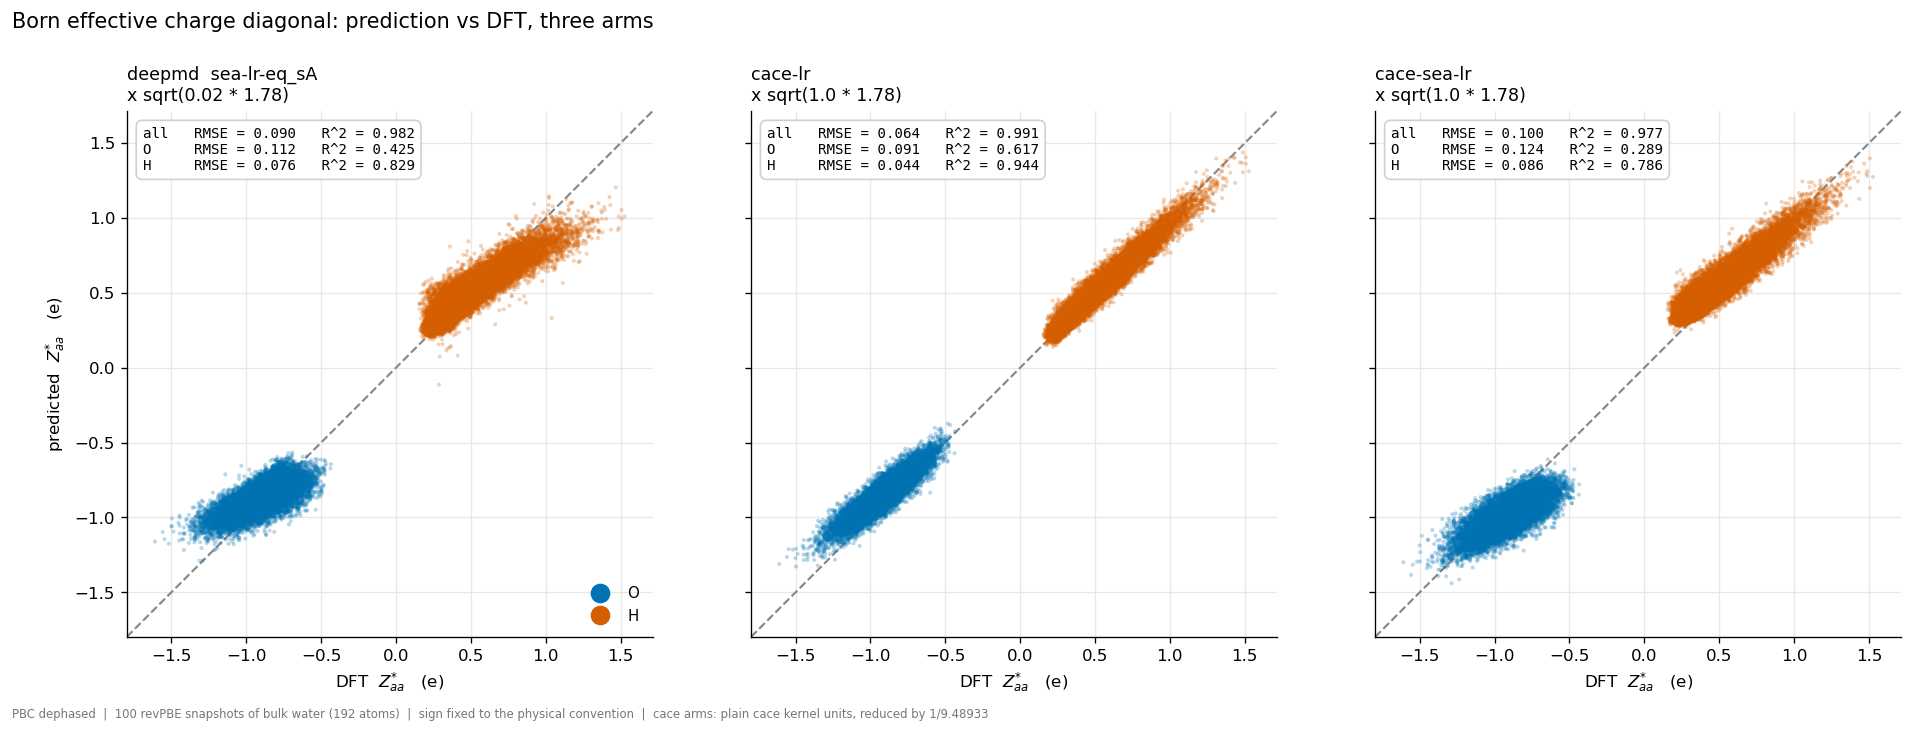

In [7]:
from matplotlib.lines import Line2D

panels = [
    ("deepmd  sea-lr-eq_sA\nx sqrt(0.02 * 1.78)", pred, dft, elem_flat),
    ("cace-lr\nx sqrt(1.0 * 1.78)", cace["cace-lr"]["pred"], dft_cace, cace["cace-lr"]["ef"]),
    ("cace-sea-lr\nx sqrt(1.0 * 1.78)", cace["cace-sea-lr"]["pred"], dft_cace, cace["cace-sea-lr"]["ef"]),
]

lo = min(p.min() for _, p, _, _ in panels + [("", dft, dft, None)])
hi = max(p.max() for _, p, _, _ in panels + [("", dft, dft, None)])
pad = 0.06 * (hi - lo)
lo, hi = lo - pad, hi + pad

fig, axes = plt.subplots(1, 3, figsize=(16.4, 6.0), dpi=120, sharex=True, sharey=True)
for ax, (title, p, d, ef) in zip(axes, panels):
    ax.plot([lo, hi], [lo, hi], color="#888888", lw=1.3, ls="--", zorder=1)
    for e in ("O", "H"):
        m = ef == e
        ax.scatter(d[m], p[m], s=6, alpha=0.28, color=COLORS[e], edgecolors="none",
                   zorder=3)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=10.5, loc="left")
    ax.grid(color="#e8e8e8", lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    rm, r2 = rmse_r2(p, d)
    rmo, r2o = rmse_r2(p[ef == "O"], d[ef == "O"])
    rmh, r2h = rmse_r2(p[ef == "H"], d[ef == "H"])
    ax.text(0.03, 0.97, f"all   RMSE = {rm:.3f}   R^2 = {r2:.3f}\n"
                        f"O     RMSE = {rmo:.3f}   R^2 = {r2o:.3f}\n"
                        f"H     RMSE = {rmh:.3f}   R^2 = {r2h:.3f}",
            transform=ax.transAxes, va="top", ha="left", fontsize=8.5,
            family="monospace",
            bbox=dict(boxstyle="round,pad=0.45", fc="white", ec="#d0d0d0"))

axes[0].set_ylabel(r"predicted  $Z^{*}_{aa}$   (e)")
for ax in axes:
    ax.set_xlabel(r"DFT  $Z^{*}_{aa}$   (e)")
axes[0].legend(
    handles=[Line2D([], [], marker="o", ls="", color=COLORS[e], markersize=6, label=e)
             for e in ("O", "H")],
    loc="lower right", frameon=False, fontsize=9, markerscale=1.8)

fig.suptitle("Born effective charge diagonal: prediction vs DFT, three arms",
             fontsize=12.5, x=0.012, ha="left", y=0.995)
fig.text(0.012, 0.014,
         "PBC dephased  |  100 revPBE snapshots of bulk water (192 atoms)  |  "
         "sign fixed to the physical convention  |  cace arms: plain cace kernel units, reduced by 1/9.48933",
         fontsize=7, color="#777777")
plt.tight_layout(rect=(0, 0.095, 1, 0.935))
plt.show()

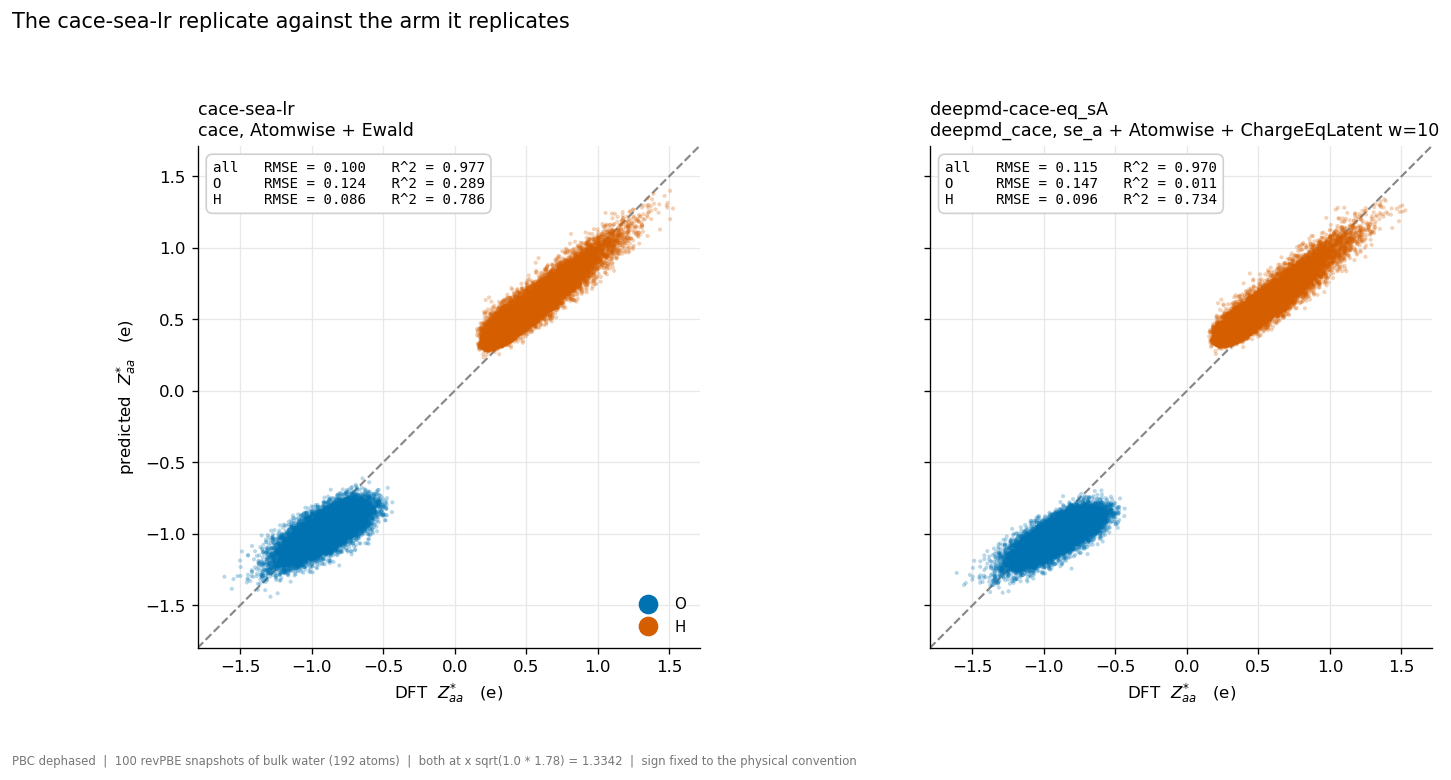

In [8]:
from matplotlib.lines import Line2D

# The replicate next to the thing it replicates. Both add the Ewald term with
# FeatureAdd and no weight, so both panels are at sqrt(1.0 * 1.78) = 1.3342 and
# are directly comparable; the difference between them is the training stack
# (deepmd descriptor + deepmd_cace + the equalizer, against cace's own).
pair = [
    ("cace-sea-lr\ncace, Atomwise + Ewald", cace["cace-sea-lr"]["pred"],
     dft_cace, cace["cace-sea-lr"]["ef"]),
    ("deepmd-cace-eq_sA\ndeepmd_cace, se_a + Atomwise + ChargeEqLatent w=10",
     pred_b, dft_b, elem_b),
]

lo = min(min(p.min() for _, p, _, _ in pair), dft_cace.min())
hi = max(max(p.max() for _, p, _, _ in pair), dft_cace.max())
pad = 0.06 * (hi - lo)
lo, hi = lo - pad, hi + pad

fig, axes = plt.subplots(1, 2, figsize=(13.0, 6.4), dpi=120, sharex=True, sharey=True)
for ax, (title, p, d, ef) in zip(axes, pair):
    ax.plot([lo, hi], [lo, hi], color="#888888", lw=1.3, ls="--", zorder=1)
    for e in ("O", "H"):
        m = ef == e
        ax.scatter(d[m], p[m], s=6, alpha=0.28, color=COLORS[e], edgecolors="none",
                   zorder=3)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=10.5, loc="left")
    ax.grid(color="#e8e8e8", lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    rm, r2 = rmse_r2(p, d)
    rmo, r2o = rmse_r2(p[ef == "O"], d[ef == "O"])
    rmh, r2h = rmse_r2(p[ef == "H"], d[ef == "H"])
    ax.text(0.03, 0.97, f"all   RMSE = {rm:.3f}   R^2 = {r2:.3f}\n"
                        f"O     RMSE = {rmo:.3f}   R^2 = {r2o:.3f}\n"
                        f"H     RMSE = {rmh:.3f}   R^2 = {r2h:.3f}",
            transform=ax.transAxes, va="top", ha="left", fontsize=8.5,
            family="monospace",
            bbox=dict(boxstyle="round,pad=0.45", fc="white", ec="#d0d0d0"))
    ax.set_xlabel(r"DFT  $Z^{*}_{aa}$   (e)")

axes[0].set_ylabel(r"predicted  $Z^{*}_{aa}$   (e)")
axes[0].legend(
    handles=[Line2D([], [], marker="o", ls="", color=COLORS[e], markersize=6, label=e)
             for e in ("O", "H")],
    loc="lower right", frameon=False, fontsize=9, markerscale=1.8)

fig.suptitle("The cace-sea-lr replicate against the arm it replicates",
             fontsize=12.5, x=0.012, ha="left", y=0.995)
fig.text(0.012, 0.014,
         "PBC dephased  |  100 revPBE snapshots of bulk water (192 atoms)  |  "
         "both at x sqrt(1.0 * 1.78) = 1.3342  |  sign fixed to the physical convention",
         fontsize=7, color="#777777")
plt.tight_layout(rect=(0, 0.095, 1, 0.925))
plt.show()

# What this run says

The arm trained to completion on the pod's 4090: 8 of 8 blocks `ok`, `returncode 0`, 80,000 steps, 8,294 s wall at 0.104 s/batch, peak 303.8 MB of GPU memory.

Scored on the 100 revPBE snapshots, dephased and at its own `sqrt(w*eps_inf) = 1.3342`, it gives `Z*_O = -1.013` and `Z*_H = +0.520` against VASP's `-0.903` and `+0.451`, with RMSE 0.115 e over all 57,600 diagonal elements, 0.147 e on O and 0.096 e on H, and `R^2` 0.970 / 0.011 / 0.734.
The run's own artifacts are in `campaign_fastlearn/deepmd/runs/deepmd-cace-eq_sA`, and `desc_bridging/vasp_bec_deepmd-cace-eq_sA.npz` holds the same numbers in the `--dump` schema.

## Against the arm it replicates

`cace-sea-lr` scores 0.100 e / 0.124 e / 0.086 e with `R^2` 0.977 / 0.289 / 0.786 on the same frames, and the gap is an offset rather than a shape error: about each arm's own mean the O residuals scatter by 0.0966 e here and 0.0986 e there, so the two agree on how `Z*_O` varies from frame to frame and differ only in the mean they vary around, this arm putting it 0.110 e from VASP where `cace-sea-lr` puts it 0.076 e.

That gap is not attributable to anything in particular, because one seed per arm is one sample. The campaign's own sibling pairs - the same recipe run twice at different seeds - end the 80,000-step schedule 1.01x and 1.06x apart on validation energy and force RMSE (`deepmd-cace-sched_sA`/`sB`) and 1.12x and 1.00x apart (`deepmd-les-cace-sched_sA`/`sB`), while this arm is 1.15x from `cace-sea-lr` on pooled BEC RMSE. At that scale the two BEC numbers are indistinguishable rather than a measured regression.

## The equalizer is not where any gap comes from

`desc_bridging/check_bec_eq_arm.py` scores the same trained weights twice on the same 100 frames, once as trained and once with `charge_eq_latent` disabled in the config; `ChargeEqLatent` holds no parameters, so the state dict loads strictly into both and the pair differs only in whether `q_eq` or the head's raw `q` enters `Polarization`.
Switching it off makes the arm worse on every measure: pooled RMSE 0.1151 -> 0.1392 e, O RMSE 0.1467 -> 0.2184, O bias -0.1104 -> -0.1964 e, `Z*_O` -1.013 -> -1.099 against VASP's -0.903, and the acoustic sum rule +1.705 -> -8.334 e per frame against VASP's 2e-06.
The paired difference is very nearly a uniform shift in the diagonal `Z*`, which is what removing a charge drift does: the head's proposal carries +7.60 e of net charge per frame and the equalizer takes it to -0.0000.
So the equalization is worth 17% of the pooled RMSE at these weights, and deleting it would widen the gap rather than close it.

## What the equalizer does, and what it does not

The head proposes `q_O = +0.876 e` and `q_H = -0.379 e`, i.e. `+62.3 e` of net charge per 64-molecule frame, and the KKT solve removes it exactly (`net/frame = -0.0000`) while moving no element by more than 4.6% of the largest proposal.

That fixes the frozen-charge part of the acoustic sum rule and much less of the rest. Freezing `q_eq` gives `sum_i Z*_i = 8.7e-06`, below the DFT reference's own `7.3e-05`; with the response included the same sum is 1.705 e per frame in the trace convention, against 2.361 e for `cace-sea-lr` and 3.556 e for `cace-lr`, all three at the same 1.3342 scale - and -8.334 e for these same weights with the equalizer off. So the surviving 1.7 e is the part a constraint on `q` itself does not reach: the derivative `dq_eq/dr`.

## The checkpoint that was scored

Every arm here is scored on `best_model.pth`, but cace's `Task.fit` resets `best_val_loss` at the top of each `fit()` call (`cace/tasks/train.py:190`), so for this arm that file is the best validation epoch *within the last block*, not over the whole schedule: it is dated 17:20:17, about six epochs into block 8, which started at 17:18:38.
The block-end model `model-4.pth` scores `Z*_O = -1.012`, `Z*_H = +0.520`, O RMSE 0.119, H RMSE 0.076, i.e. within 0.002 e, so which of the two is quoted does not matter here.


---
# Per-element linear regression against DFT

The same three arms and the same 57,600 diagonal elements as in the figures above, but now each element is fitted with a least-squares line `real = a + b * predicted` and summarized by the Pearson correlation coefficient `r`.

- **The axes are flipped against the figures above.** The regression reads the real value as the response, so here predicted is on x and DFT is on y (above it was the other way round). `r` is symmetric and does not depend on that choice; `b` and `a` do, and they are quoted in this real-on-predicted orientation.
- **Per element, not pooled.** Pooling O and H would put `r` above 0.99 for every arm, because the two elements sit in well-separated clouds - that number would measure the O/H gap, not the model. Within an element, `r` measures whether the arm tracks the frame-to-frame variation at all.
- **What the two numbers separate.** `r` is invariant under any affine recalibration of the prediction (`pred -> u * pred + v` leaves it unchanged), so it is the shape agreement. `b = 1`, `a = 0` means the arm is already on the DFT scale; a `b` away from 1 or an `a` away from 0 is calibration that the fit could absorb, and `resid sd` - the spread left after the fit - is the error no affine recalibration removes.
- Caveat on `n`: the values are 100 frames x 192 atoms x 3 diagonal components, and atoms within a frame are strongly correlated, so the effective sample per element is nearer the 100 frames than the printed `n`.

In [9]:
def regress_per_element(p, d, ef):
    """Least-squares `real = a + b * predicted`, per element.

    `r` is Pearson's coefficient; it is symmetric, so the same whichever way the
    regression is read, unlike `b` and `a`.
    """
    out = {}
    for e in ("O", "H"):
        m = ef == e
        b, a = np.polyfit(p[m], d[m], 1)
        r = float(np.corrcoef(p[m], d[m])[0, 1])
        res = d[m] - (b * p[m] + a)
        out[e] = dict(m=m, n=int(m.sum()), b=float(b), a=float(a), r=r,
                      resid_sd=float(res.std()))
    return out


REGRESSION_ARMS = [
    ("cace-lr",           cace["cace-lr"]["pred"],     dft_cace, cace["cace-lr"]["ef"]),
    ("cace-sea-lr",       cace["cace-sea-lr"]["pred"], dft_cace, cace["cace-sea-lr"]["ef"]),
    ("deepmd-cace-eq_sA", pred_b,                      dft_b,    elem_b),
]

fits = {}
print(f"{'arm':20s}{'elem':>5s}{'n':>8s}{'r':>8s}{'R^2':>8s}"
      f"{'slope b':>9s}{'intercept a':>12s}{'resid sd':>10s}")
for name, p, d, ef in REGRESSION_ARMS:
    fits[name] = regress_per_element(p, d, ef)
    for e in ("O", "H"):
        f = fits[name][e]
        print(f"{name:20s}{e:>5s}{f['n']:8,d}{f['r']:8.3f}{f['r'] ** 2:8.3f}"
              f"{f['b']:9.3f}{f['a']:+12.3f}{f['resid_sd']:10.3f}")

arm                  elem       n       r     R^2  slope b intercept a  resid sd
cace-lr                 O  19,200   0.907   0.822    1.085      +0.005     0.062
cace-lr                 H  38,400   0.972   0.945    1.012      +0.000     0.044
cace-sea-lr             O  19,200   0.745   0.555    1.069      +0.143     0.098
cace-sea-lr             H  38,400   0.942   0.887    1.105      -0.110     0.062
deepmd-cace-eq_sA       O  19,200   0.763   0.583    1.164      +0.276     0.095
deepmd-cace-eq_sA       H  38,400   0.941   0.885    1.147      -0.145     0.063


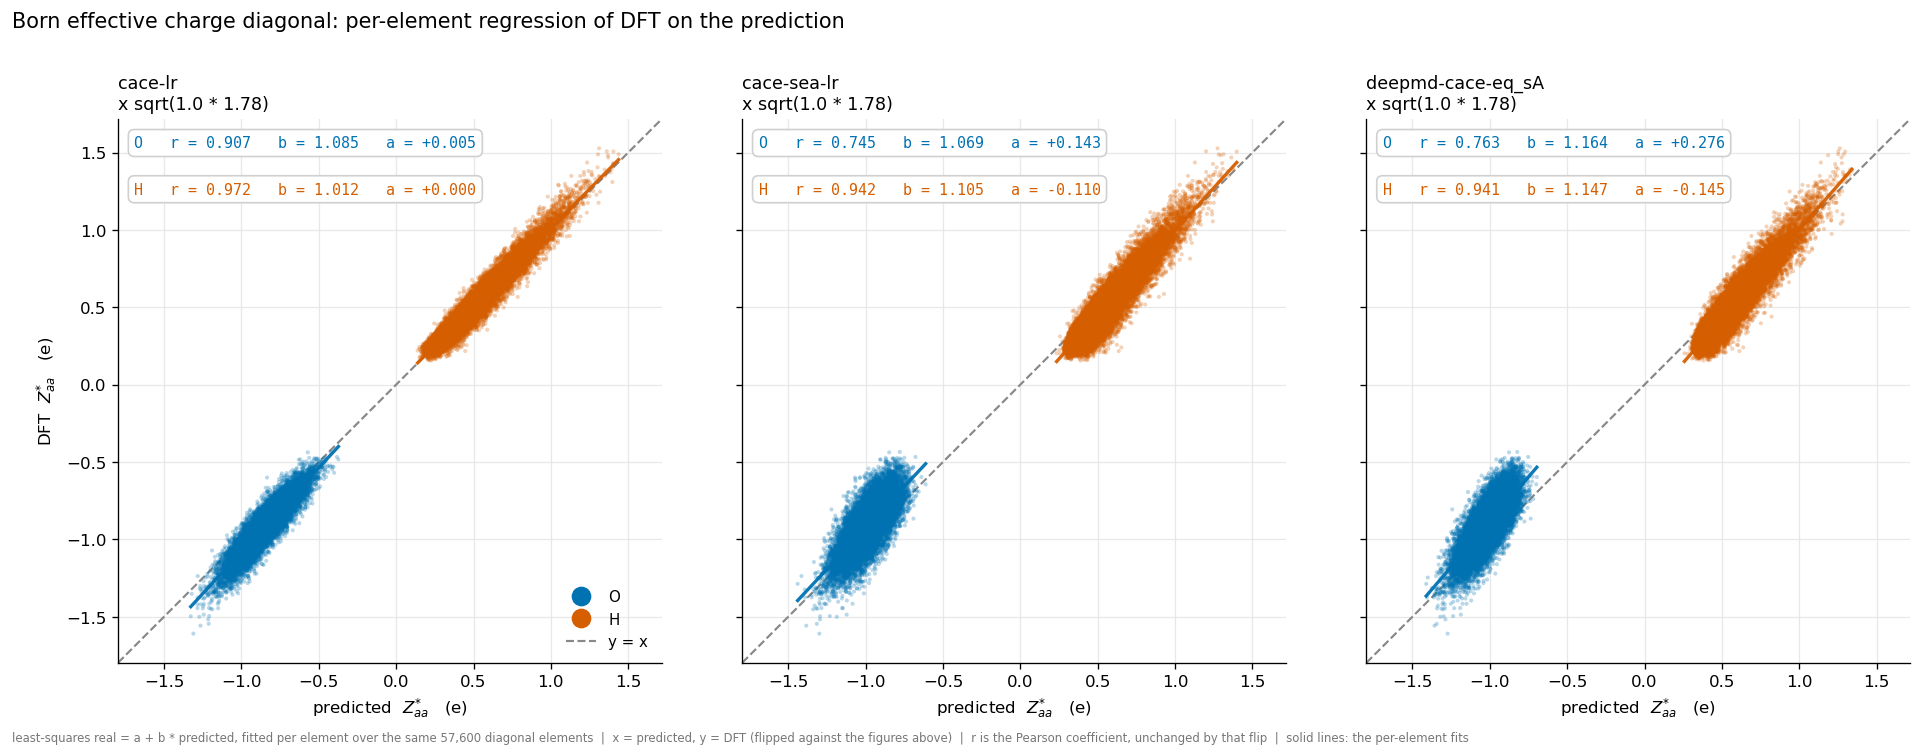

In [10]:
from matplotlib.lines import Line2D

lo = min(min(p.min() for _, p, _, _ in REGRESSION_ARMS), dft_cace.min(), dft_b.min())
hi = max(max(p.max() for _, p, _, _ in REGRESSION_ARMS), dft_cace.max(), dft_b.max())
pad = 0.06 * (hi - lo)
lo, hi = lo - pad, hi + pad

fig, axes = plt.subplots(1, 3, figsize=(16.4, 6.2), dpi=120, sharex=True, sharey=True)
for ax, (name, p, d, ef) in zip(axes, REGRESSION_ARMS):
    ax.plot([lo, hi], [lo, hi], color="#888888", lw=1.3, ls="--", zorder=1)
    for e in ("O", "H"):
        m = ef == e
        f = fits[name][e]
        ax.scatter(p[m], d[m], s=6, alpha=0.28, color=COLORS[e], edgecolors="none",
                   zorder=3)
        xs = np.array([p[m].min(), p[m].max()])
        ax.plot(xs, f["b"] * xs + f["a"], color=COLORS[e], lw=2.0, alpha=0.95, zorder=4)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal")
    ax.set_title(f"{name}\nx sqrt(1.0 * 1.78)", fontsize=10.5, loc="left")
    ax.grid(color="#e8e8e8", lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.set_xlabel(r"predicted  $Z^{*}_{aa}$   (e)")
    for i, e in enumerate(("O", "H")):
        f = fits[name][e]
        ax.text(0.03, 0.97 - 0.085 * i,
                f"{e}   r = {f['r']:.3f}   b = {f['b']:.3f}   a = {f['a']:+.3f}",
                transform=ax.transAxes, va="top", ha="left", fontsize=9,
                family="monospace", color=COLORS[e],
                bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#d0d0d0"))

axes[0].set_ylabel(r"DFT  $Z^{*}_{aa}$   (e)")
axes[0].legend(
    handles=[Line2D([], [], marker="o", ls="", color=COLORS[e], markersize=6, label=e)
             for e in ("O", "H")]
    + [Line2D([], [], color="#888888", lw=1.3, ls="--", label="y = x")],
    loc="lower right", frameon=False, fontsize=9, markerscale=1.8)

fig.suptitle("Born effective charge diagonal: per-element regression of DFT on the prediction",
             fontsize=12.5, x=0.012, ha="left", y=0.995)
fig.text(0.012, 0.014,
         "least-squares real = a + b * predicted, fitted per element over the same 57,600 diagonal elements  |  "
         "x = predicted, y = DFT (flipped against the figures above)  |  "
         "r is the Pearson coefficient, unchanged by that flip  |  solid lines: the per-element fits",
         fontsize=7, color="#777777")
plt.tight_layout(rect=(0, 0.095, 1, 0.925))
plt.show()

---
# The same predictions after their per-element recalibration

The fit above read as a correction: `b * predicted + a`, with each element's own `b` and `a`. This is that corrected output against DFT, back in the notebook's main convention (DFT on x, model on y, as in the first figures - the flipped axes belong to the regression figure only).

- The clouds move onto `y = x` as far as an affine map can carry them; whatever spread is left over is the shape error that no recalibration removes, which is what the fitted `r` measures.
- Because each fit carries an intercept, every element's mean is matched exactly, so the post-fit bias is 0.000 e by construction - which is why no bias column appears below. The `RMSE before -> after` pair is the honest "how much of this element's error was calibration" number.
- `before` is the fixed-scale prediction of the figures above (scale 1, no recalibration); `after` is `b * predicted + a`.

In [11]:
calib = {}
print(f"{'arm':20s}{'elem':>5s}{'r':>8s}{'RMSE before':>13s}{'RMSE after':>12s}{'removed':>9s}")
for name, p, d, ef in REGRESSION_ARMS:
    calib[name] = dict(reg=np.asarray(p, dtype=np.float64).copy())
    for e in ("O", "H"):
        m = ef == e
        f = fits[name][e]
        reg = f["b"] * p[m] + f["a"]
        calib[name]["reg"][m] = reg
        before = float(np.sqrt(np.mean((p[m] - d[m]) ** 2)))
        after = float(np.sqrt(np.mean((reg - d[m]) ** 2)))     # = the fit's residual sd
        bias = float(np.mean(reg - d[m]))                      # exactly 0: the fit has an intercept
        assert abs(bias) < 1e-6, f"post-fit bias {bias}"
        calib[name][f"before_{e}"], calib[name][f"after_{e}"] = before, after
        print(f"{name:20s}{e:>5s}{f['r']:8.3f}{before:13.3f}{after:12.3f}"
              f"{100 * (before - after) / before:8.1f}%")

arm                  elem       r  RMSE before  RMSE after  removed
cace-lr                 O   0.907        0.091       0.062    31.9%
cace-lr                 H   0.972        0.044       0.044     0.8%
cace-sea-lr             O   0.745        0.124       0.098    20.9%
cace-sea-lr             H   0.942        0.086       0.062    27.2%
deepmd-cace-eq_sA       O   0.763        0.147       0.095    35.1%
deepmd-cace-eq_sA       H   0.941        0.096       0.063    34.4%


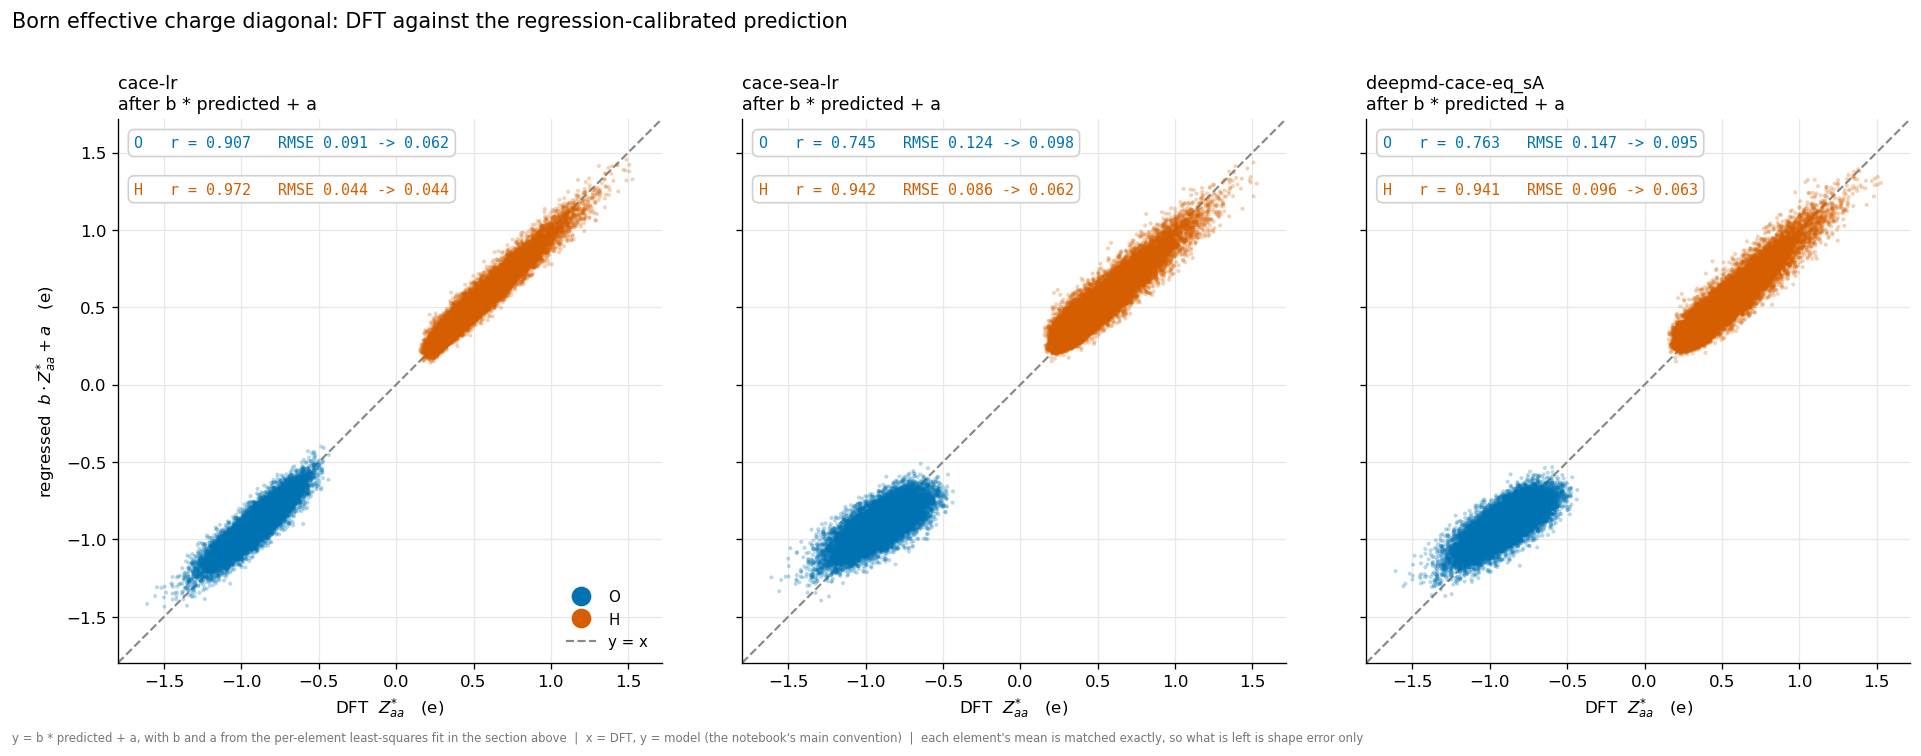

In [12]:
from matplotlib.lines import Line2D

pairs = [(name, calib[name]["reg"], d, ef) for name, p, d, ef in REGRESSION_ARMS]
lo = min(min(r.min() for _, r, _, _ in pairs), min(d.min() for _, _, d, _ in pairs))
hi = max(max(r.max() for _, r, _, _ in pairs), max(d.max() for _, _, d, _ in pairs))
pad = 0.06 * (hi - lo)
lo, hi = lo - pad, hi + pad

fig, axes = plt.subplots(1, 3, figsize=(16.4, 6.2), dpi=120, sharex=True, sharey=True)
for ax, (name, reg, d, ef) in zip(axes, pairs):
    ax.plot([lo, hi], [lo, hi], color="#888888", lw=1.3, ls="--", zorder=1)
    for e in ("O", "H"):
        m = ef == e
        ax.scatter(d[m], reg[m], s=6, alpha=0.28, color=COLORS[e], edgecolors="none",
                   zorder=3)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal")
    ax.set_title(f"{name}\nafter b * predicted + a", fontsize=10.5, loc="left")
    ax.grid(color="#e8e8e8", lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.set_xlabel(r"DFT  $Z^{*}_{aa}$   (e)")
    for i, e in enumerate(("O", "H")):
        ax.text(0.03, 0.97 - 0.085 * i,
                f"{e}   r = {fits[name][e]['r']:.3f}   "
                f"RMSE {calib[name][f'before_{e}']:.3f} -> {calib[name][f'after_{e}']:.3f}",
                transform=ax.transAxes, va="top", ha="left", fontsize=9,
                family="monospace", color=COLORS[e],
                bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#d0d0d0"))

axes[0].set_ylabel(r"regressed  $b \cdot Z^{*}_{aa} + a$   (e)")
axes[0].legend(
    handles=[Line2D([], [], marker="o", ls="", color=COLORS[e], markersize=6, label=e)
             for e in ("O", "H")]
    + [Line2D([], [], color="#888888", lw=1.3, ls="--", label="y = x")],
    loc="lower right", frameon=False, fontsize=9, markerscale=1.8)

fig.suptitle("Born effective charge diagonal: DFT against the regression-calibrated prediction",
             fontsize=12.5, x=0.012, ha="left", y=0.995)
fig.text(0.012, 0.014,
         "y = b * predicted + a, with b and a from the per-element least-squares fit in the section above  |  "
         "x = DFT, y = model (the notebook's main convention)  |  "
         "each element's mean is matched exactly, so what is left is shape error only",
         fontsize=7, color="#777777")
plt.tight_layout(rect=(0, 0.095, 1, 0.925))
plt.show()